In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display and plotting configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Load cleaned transaction dataset
processed_path = '../data/processed/cleaned_online_retail.csv'
df = pd.read_csv(processed_path, low_memory=False)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Loaded {len(df):,} transactions from {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}.")

Loaded 1,021,452 transactions from 2009-12-01 to 2011-12-09.


In [2]:
# Aggregate demand to daily level across all products
daily_demand = df.groupby(df['InvoiceDate'].dt.date)['Net_Quantity'].sum().reset_index()
daily_demand.columns = ['Date', 'Quantity']
daily_demand['Date'] = pd.to_datetime(daily_demand['Date'])

# Reindex across full continuous date range to reveal missing operational days
full_date_range = pd.date_range(start=daily_demand['Date'].min(), end=daily_demand['Date'].max(), freq='D')
daily_full = daily_demand.set_index('Date').reindex(full_date_range, fill_value=0).reset_index()
daily_full.columns = ['Date', 'Quantity']

# Calculate key statistics on daily demand
zero_days = (daily_full['Quantity'] == 0).sum()
total_days = len(daily_full)

print("--- DAILY DEMAND CHARACTERISTICS ---")
print(f"Total Calendar Days:     {total_days}")
print(f"Zero-Demand / Gap Days:  {zero_days} ({(zero_days / total_days) * 100:.2f}%)")
print(f"Mean Daily Demand:       {daily_full['Quantity'].mean():.2f} units")
print(f"Std Dev Daily Demand:    {daily_full['Quantity'].std():.2f}")
print(f"Coefficient of Var (CV): {daily_full['Quantity'].std() / daily_full['Quantity'].mean():.2f}")

--- DAILY DEMAND CHARACTERISTICS ---
Total Calendar Days:     739
Zero-Demand / Gap Days:  135 (18.27%)
Mean Daily Demand:       14506.64 units
Std Dev Daily Demand:    12559.41
Coefficient of Var (CV): 0.87


In [3]:
# Aggregate demand to Weekly level (W-MON: Week starting Mondays)
weekly_demand = df.set_index('InvoiceDate').resample('W-MON')['Net_Quantity'].sum().reset_index()
weekly_demand.columns = ['Week_Start', 'Quantity']

# Calculate key statistics on weekly demand
zero_weeks = (weekly_demand['Quantity'] == 0).sum()
total_weeks = len(weekly_demand)

print("--- WEEKLY DEMAND CHARACTERISTICS ---")
print(f"Total Continuous Weeks:  {total_weeks}")
print(f"Zero-Demand Weeks:       {zero_weeks} ({(zero_weeks / total_weeks) * 100:.2f}%)")
print(f"Mean Weekly Demand:      {weekly_demand['Quantity'].mean():.2f} units")
print(f"Std Dev Weekly Demand:   {weekly_demand['Quantity'].std():.2f}")
print(f"Coefficient of Var (CV): {weekly_demand['Quantity'].std() / weekly_demand['Quantity'].mean():.2f}")

--- WEEKLY DEMAND CHARACTERISTICS ---
Total Continuous Weeks:  106
Zero-Demand Weeks:       1 (0.94%)
Mean Weekly Demand:      101135.92 units
Std Dev Weekly Demand:   39923.25
Coefficient of Var (CV): 0.39


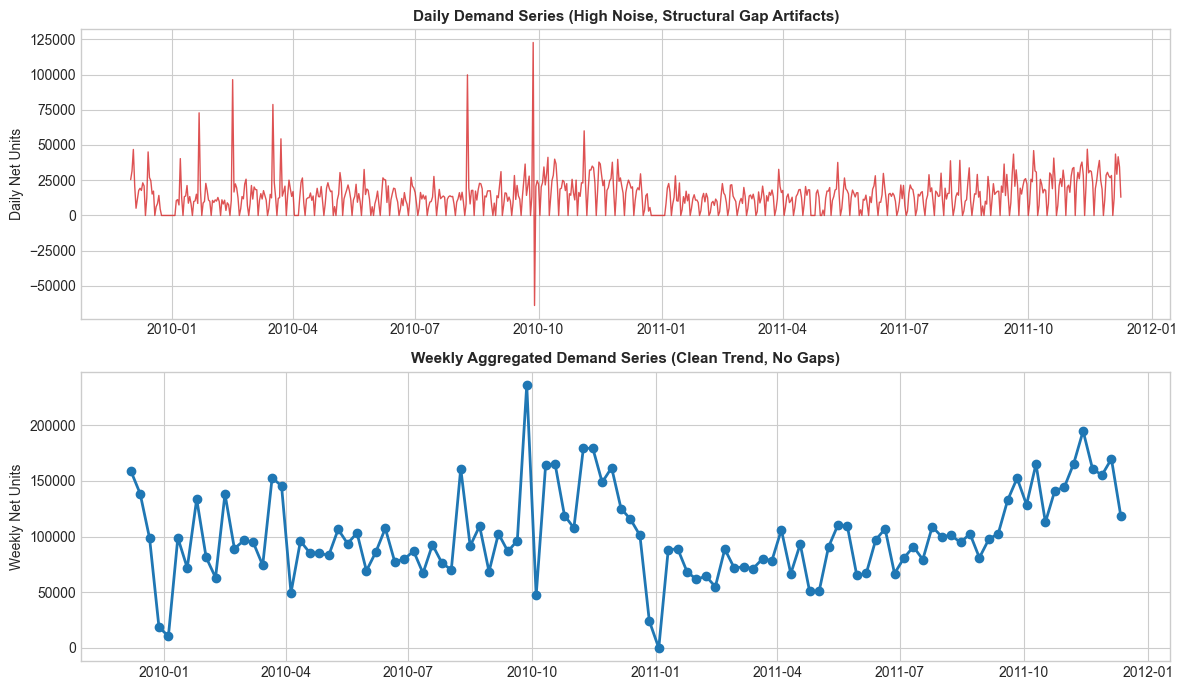

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# Daily Plot
ax1.plot(daily_full['Date'], daily_full['Quantity'], color='#d62728', linewidth=1, alpha=0.8)
ax1.set_title('Daily Demand Series (High Noise, Structural Gap Artifacts)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Daily Net Units')

# Weekly Plot
ax2.plot(weekly_demand['Week_Start'], weekly_demand['Quantity'], color='#1f77b4', linewidth=2, marker='o')
ax2.set_title('Weekly Aggregated Demand Series (Clean Trend, No Gaps)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Weekly Net Units')

plt.tight_layout()
plt.show()

In [5]:
# Resample product demand per week
product_weekly = df.groupby(['StockCode', pd.Grouper(key='InvoiceDate', freq='W-MON')])['Net_Quantity'].sum().reset_index()

# Calculate SKU forecastability metrics
sku_metrics = product_weekly.groupby('StockCode').agg(
    Active_Weeks=('Net_Quantity', lambda x: (x > 0).sum()),
    Total_Weeks=('Net_Quantity', 'count'),
    Total_Units=('Net_Quantity', 'sum'),
    Mean_Weekly_Units=('Net_Quantity', 'mean'),
    Std_Weekly_Units=('Net_Quantity', 'std')
).reset_index()

# Calculate Coefficient of Variation (CV) for demand volatility
sku_metrics['CV'] = sku_metrics['Std_Weekly_Units'] / sku_metrics['Mean_Weekly_Units']

# Apply Objective Selection Mask
selection_mask = (
    (sku_metrics['Active_Weeks'] >= 40) & 
    (sku_metrics['Total_Units'] >= 500) & 
    (sku_metrics['CV'] < 2.5)
)

selected_skus = sku_metrics[selection_mask].sort_values(by='Total_Units', ascending=False).reset_index(drop=True)

print("--- OBJECTIVE SKU SELECTION RESULTS ---")
print(f"Total Unique SKUs in Dataset:   {len(sku_metrics):,}")
print(f"SKUs Meeting Criteria:          {len(selected_skus):,} ({(len(selected_skus)/len(sku_metrics))*100:.2f}%)")
print(f"Volume Coverage of Selected:   {(selected_skus['Total_Units'].sum() / df['Net_Quantity'].sum()) * 100:.2f}% of overall company volume")

display(selected_skus.head(10))

--- OBJECTIVE SKU SELECTION RESULTS ---
Total Unique SKUs in Dataset:   4,920
SKUs Meeting Criteria:          1,676 (34.07%)
Volume Coverage of Selected:   77.77% of overall company volume


,StockCode,Active_Weeks,Total_Weeks,Total_Units,Mean_Weekly_Units,Std_Weekly_Units,CV
0,84077,103,103,104435,1013.93,1006.55,0.99
1,85099B,105,105,95544,909.94,481.05,0.53
2,21212,104,104,93774,901.67,494.11,0.55
3,85123A,105,105,90566,862.53,547.36,0.63
4,22197,105,105,87695,835.19,936.66,1.12
5,84879,104,104,79571,765.11,699.91,0.91
6,17003,98,98,69629,710.50,1525.48,2.15
7,21977,104,104,55842,536.94,398.50,0.74
8,84991,105,105,53678,511.22,337.07,0.66
9,15036,101,103,43343,420.81,506.14,1.20


In [ ]:
# Filter weekly demand for selected forecastable SKUs
top_sku_list = selected_skus['StockCode'].tolist()

# Aggregate continuous weekly demand for selected SKUs
forecast_df = df[df['StockCode'].isin(top_sku_list)].groupby(
    ['StockCode', pd.Grouper(key='InvoiceDate', freq='W-MON')]
)['Net_Quantity'].sum().reset_index()

forecast_df.columns = ['StockCode', 'Week_Start', 'Quantity']

# Save processed weekly time-series dataset
output_path = '../data/processed/weekly_sku_demand.csv'
forecast_df.to_csv(output_path, index=False)

print(f"\nForecast-ready weekly dataset saved successfully to: {output_path}")
print(f"Dataset shape: {forecast_df.shape[0]:,} rows across {len(top_sku_list)} qualified SKUs.")